#Building your Deep Neural Network: Step by Step

We have previously trained a 2-layer Neural Network (with a single hidden layer). Here,we will build a deep neural network, with as many layers as you want!

In this notebook, we will implement all the functions required to build a deep neural network.

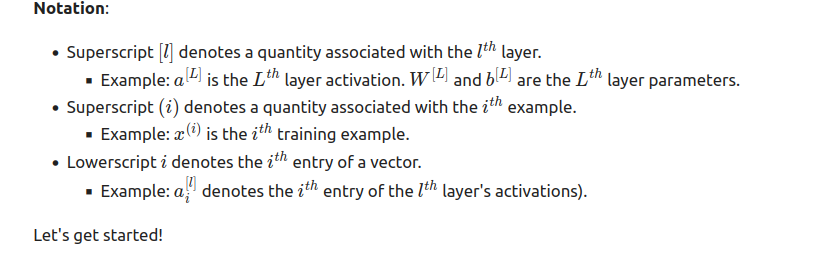

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from testCases import *
from dnn_utils import sigmoid, sigmoid_backward, relu, relu_backward


%matplotlib inline
plt.rcParams['figure.figsize'] = (5.0, 4.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# %load_ext autoreload
# %autoreload 2

np.random.seed(1)


## Outline of the NoteBook
To build your neural network, we will be implementing several "helper functions". These helper functions will be used in the next assignment to build a two-layer neural network and an L-layer neural network. Each small helper function you will implement will have detailed instructions that will walk you through the necessary steps. Here is an outline of this assignment, we will:
* Initialize the parameters for a two-layer network and for an L-layer neural network.
* Implement the forward propagation module (shown in purple in the figure below).
 * Complete the LINEAR part of a layer's forward propagation step (resulting in $Z^{[l]}$)
 * We given  the ACTIVATION function (relu/sigmoid).
 * Combine the previous two steps into a new [LINEAR->ACTIVATION] forward function.
 * Stack the [LINEAR->RELU] forward function L-1 time (for layers 1 through L-1) and add a [LINEAR->SIGMOID] at the end (for the final layer L). This gives you a new L_model_forward function.
* compute the loss
* Implement the backward propagation module (denoted in red in the figure below).
  * Complete the LINEAR part of a layer's backward propagation step.
  * We are given  the gradient of the ACTIVATE function (relu_backward/sigmoid_backward)

  * Combine the previous two steps into a new [LINEAR->ACTIVATION] backward function.
  * Stack [LINEAR->RELU] backward L-1 times and add [LINEAR->SIGMOID] backward in a new L_model_backward function

* Finally update the parameters
  

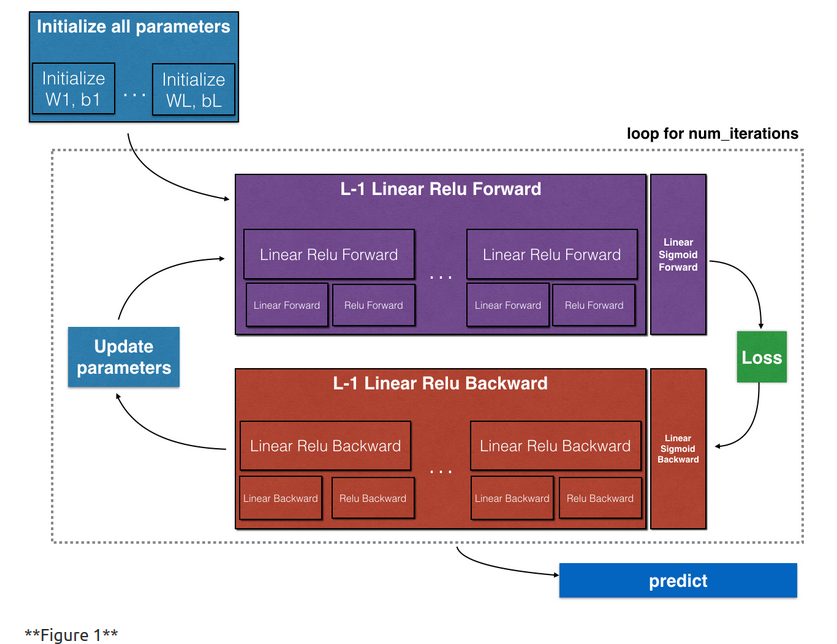

**Note**- that for every forward function, there is a corresponding backward function. That is why at every step of your forward module you will be storing some values in a cache. The cached values are useful for computing gradients. In the backpropagation module you will then use the cache to calculate the gradients. This assignment will show you exactly how to carry out each of these steps.

## Initialization

We will write two helper functions that will initialize the parameters for the model. The first function will be used to initialize parameters for a two layer model. The second one will generalize this initialization process to L layers.

### 2-layer Neural Network
Here we , Create and initialize the parameters of the 2-layer neural network.

**instructions**
* The model's structure is: LINEAR -> RELU -> LINEAR -> SIGMOID.
* Use random initialization for the weight matrices. Use `np.random.randn(shape)*0.01` with the correct shape.
* use zero initialization for the biases. Use `np.zeros(shape)`.


In [2]:
# Initailizing parametrs

def initialize_parameters(n_x, n_h, n_y):
  """
  Argument:
  n_x : size of te input layer
  n_h -- size of the hidden layer
  n_y -- size of the output layer

  Returns:
  parameters -- python dict containing the parameters
                 W1 -- weight matrix of shape (n_h, n_x)
                 b1 -- bias vector of shape (n_h, 1)
                 W2 -- weight matrix of shape (n_y, n_h)
                 b2 -- bias vector of shape (n_y, 1)
  """

  np.random.seed(1)

  W1 = np.random.randn(n_h, n_x) * 0.01
  b1 = np.zeros(shape=(n_h, 1))
  W2 = np.random.randn(n_y, n_h) * 0.01
  b2 = np.zeros(shape=(n_y, 1))

  assert(W1.shape == (n_h, n_x))
  assert(b1.shape == (n_h, 1))
  assert(W2.shape == (n_y, n_h))
  assert(b2.shape== (n_y, 1))

  parameters = {
      "W1": W1,
      "b1": b1,
      "W2": W2,
      "b2": b2

      }

  return parameters





In [3]:
parameters = initialize_parameters(2, 2, 1)
print("W1  = " + str(parameters["W1"]))
print("b1  = " + str(parameters["b1"]))
print("W2  = " + str(parameters["W2"]))
print("b2  = " + str(parameters["b2"]))


W1  = [[ 0.01624345 -0.00611756]
 [-0.00528172 -0.01072969]]
b1  = [[0.]
 [0.]]
W2  = [[ 0.00865408 -0.02301539]]
b2  = [[0.]]


## L-Layer NN
The initialization for a deeper L-layer neural network is more complicated because there are many more weight matrices and bias vectors. When completing the initialize_parameters_deep, you should make sure that your dimensions match between each layer. Recall that $n^{[l]}$ is the number of units in the layer l. Thus for example if the size of our input X is (12288, 209) (with m = 209 examples) then :


<tr>
    <td></td>
    <td><b>Shape of W</b></td>
    <td><b>Shape of b</b></td>
    <td><b>Linear / Activation</b></td>
    <td><b>Shape</b></td>
</tr>

<tr>
    <td><b>Layer 1</b></td>
    <td>$(n^{[1]}, 12288)$</td>
    <td>$(n^{[1]}, 1)$</td>
    <td>
        $Z^{[1]} = W^{[1]} X + b^{[1]}$ <br>
        $A^{[1]} = g^{[1]}(Z^{[1]})$
    </td>
    <td>$(n^{[1]}, m)$</td>
</tr>

<tr>
    <td><b>Layer 2</b></td>
    <td>$(n^{[2]}, n^{[1]})$</td>
    <td>$(n^{[2]}, 1)$</td>
    <td>
        $Z^{[2]} = W^{[2]} A^{[1]} + b^{[2]}$ <br>
        $A^{[2]} = g^{[2]}(Z^{[2]})$
    </td>
    <td>$(n^{[2]}, m)$</td>
</tr>

<tr>
    <td>$\vdots$</td>
    <td>$\vdots$</td>
    <td>$\vdots$</td>
    <td>$\vdots$</td>
    <td>$\vdots$</td>
</tr>


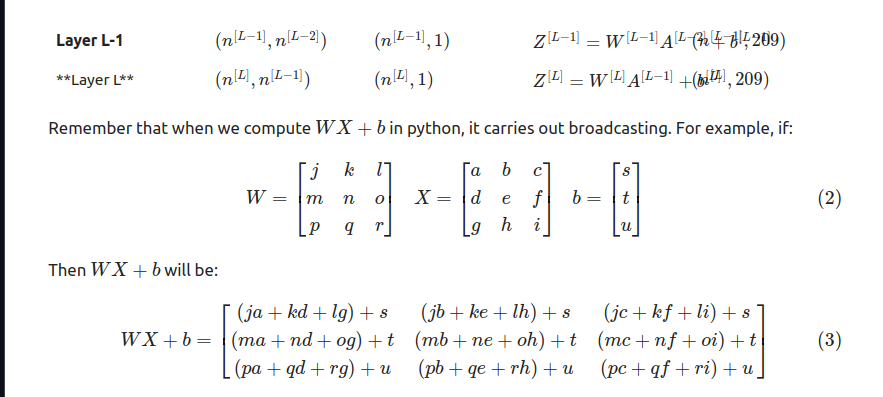

Implementing the initialization of te L-layer Neural Network

**Instructions**
* The model's structure is [LINEAR -> RELU] X (L-1) -> LINEAR -> SIGMOID. I.e., it has L - 1 layers using a ReLU activation function followed by an output layer with a sigmoid activation function.
* Use random initialization for the weight matrices. Use `np.random.rand(shape) * 0.01`.
* Use zeros initialization for the biases. Use `np.zeros(shape)`.
* We'll stire $n^{[l]}$ , the number of units in different layers, in a variable `layer_dims`. For example, the `layer_dims` for the "Planar Data classification model" from last week would have been [2,4,1]: There were two inputs, one hidden layer with 4 hidden units, and an output layer with 1 output unit. Thus means `W1`'s shape was (4,2), `b1` was (4,1), `W2` was (1,4) and `b2` was (1,1). Now you will generalize this to layers!

* Here is the implementation for L = 1 (one layer neural network). It should inspire you to implement the general case (L-layer neural network).

  if L == 1:
        parameters["W" + str(L)] = np.random.randn(layer_dims[1], layer_dims[0]) * 0.01
        parameters["b" + str(L)] = np.zeros((layer_dims[1], 1))



In [4]:
def initialize_parameters_deep(layer_dims):
  """
  Arguments:
  layerr_dims: python array (list) containing the dimensions of each layer in our network

  Returns :
  parameters --    python dictionary containing your parameters "W1", "b1", ..., "WL", "bL":
                    Wl -- weight matrix of shape (layer_dims[l], layer_dims[l-1])
                    bl -- bias vector of shape (layer_dims[l], 1)
  """

  np.random.seed(32)

  parameters = {}
  L = len(layer_dims)    # Number of layer in the network

  for l in range(1, L):
    parameters["W" + str(l)] = np.random.randn(layer_dims[l], layer_dims[l - 1]) * 0.01
    parameters['b' + str(l)] = np.zeros((layer_dims[l], 1))

    assert(parameters['W' + str(l)].shape == (layer_dims[l], layer_dims[l - 1]))
    assert(parameters['b' + str(l)].shape == (layer_dims[l], 1))
  return parameters








In [5]:
parameters = initialize_parameters_deep([5, 4, 3])

print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))

W1 = [[-0.00348894  0.00983703  0.00580923  0.00070284  0.00777533]
 [ 0.00581959  0.01471791  0.01663181 -0.00261177 -0.00688677]
 [-0.00694923  0.01940423  0.01805415  0.00456314 -0.00574812]
 [ 0.00114181  0.01513581  0.00351132 -0.00088933  0.00916954]]
b1 = [[0.]
 [0.]
 [0.]
 [0.]]
W2 = [[ 0.00505645 -0.00815271  0.00389151 -0.00424962]
 [ 0.00039623 -0.00527964 -0.00510304 -0.00888285]
 [ 0.01087625  0.00673392 -0.01067317  0.0121805 ]]
b2 = [[0.]
 [0.]
 [0.]]


## Forward Propagation Module
### Linear Forward
Now that we have initialized wer parameters, we will do the forward propagation module. we will start by implementing some basic functions that we will use later when implementing the model. we will complete three functions in this order:

* LINEAR
* LINEAR -> ACTIVATION where ACTIVATION will be either ReLU or Sigmoid.
* [LINEAR -> RELU] X (L-1) -> LINEAR -> SIGMOID (whole model)
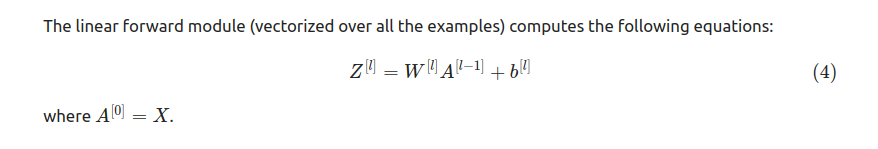

Building the linear part of the forward propagation.



In [6]:
def linear_forward(A, W, b):
  """
  Implement the linear part of a layer's forward propagation.

  Arguments:
  A -- activations from previous layer (or input data): (size of previous layer, number of examples)
  W -- weights matrix: numpy array of shape (size of current layer, size of previous layer)
  b -- bias vector, numpy array of shape (size of the current layer, 1)

  Returns:
  Z -- the input of the activation function, also called pre-activation parameter
  cache -- a python dictionary containing "A", "W" and "b" ; stored for computing the backward pass efficiently
  """

  Z = np.dot(W, A) + b

  assert (Z.shape == (W.shape[0], A.shape[1]))

  cache = (A, W, b)

  return Z, cache


In [7]:
A, W , b = linear_forward_test_case()

Z, linear_cache = linear_forward(A, W, b)

print("Z = " + str(Z))

Z = [[ 3.76169412 -0.73555912]]


## Linear-Activation Forward
Here we use 2 activation functions:
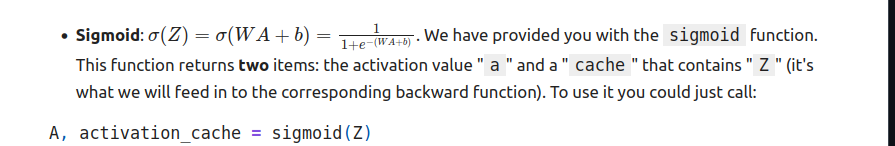


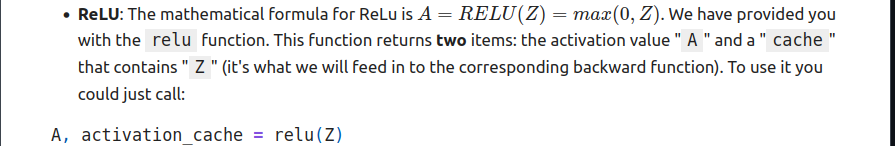


For more convenience, we are going to group two functions (Linear and Activation) into one function (LINEAR->ACTIVATION). Hence, we will implement a function that does the LINEAR forward step followed by an ACTIVATION forward step.

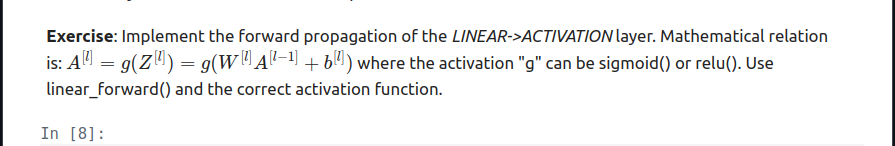

In [8]:
def linear_activation_forward(A_prev, W, b, activation):
  """
  Implement the forward propagation for the LINEAR->ACTIVATION layer

  Arguments:
  A_prev -- activations from previous layer (or input data): (size of previous layer, number of examples)
  W -- weights matrix: numpy array of shape (size of current layer, size of previous layer)
  b -- bias vector, numpy array of shape (size of the current layer, 1)
  activation -- the activation to be used in this layer, stored as a text string: "sigmoid" or "relu"

  Returns:
  A -- the output of the activation function, also called the post-activation value
  cache -- a python dictionary containing "linear_cache" and "activation_cache";
            stored for computing the backward pass efficiently
  """

  if activation == "sigmoid":
    Z , linear_cache = linear_forward(A_prev, W, b)
    A, activation_cache = sigmoid(Z)
  elif activation == "relu":
    Z, linear_cache = linear_forward(A_prev,W, b)
    A, activation_cache = relu(Z)

  assert (A.shape == (W.shape[0], A_prev.shape[1]))
  cache = (linear_cache, activation_cache)

  return A, cache


In [9]:
A_prev , W, b = linear_activation_forward_test_case()

A, liner_activation_cache = linear_activation_forward(A_prev,  W, b, activation="sigmoid")
print("With sigmoid: A = " + str(A))

A, linear_activation_cache = linear_activation_forward(A_prev, W, b, activation="relu")

print("With ReLU: A  = " + str(A))

With sigmoid: A = [[0.96890023 0.11013289]]
With ReLU: A  = [[3.43896131 0.        ]]




Note: In deep learning, the "[LINEAR->ACTIVATION]" computation is counted as a single layer in the neural network, not two layers.


### d_layer Model

For even more convenience when implementing the L-layer Neural Net, you will need a function that replicates the previous one (`linear_activation_forward` with RELU) L -1  times, then follows that with one `linear_activation_forward` with SIGMOID.

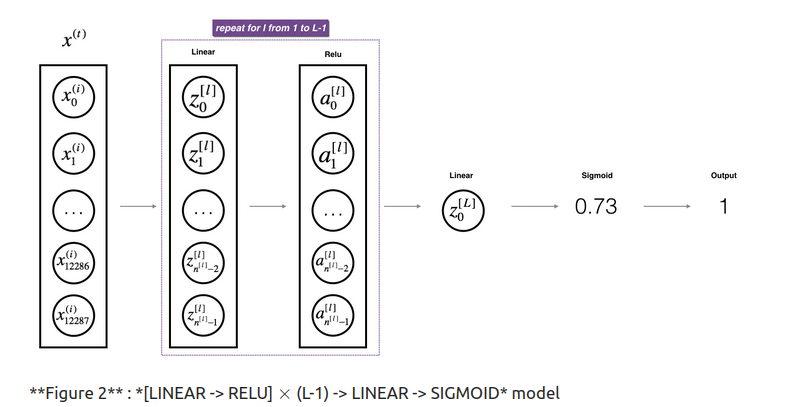

Next we implement the forward propagation of the above model.
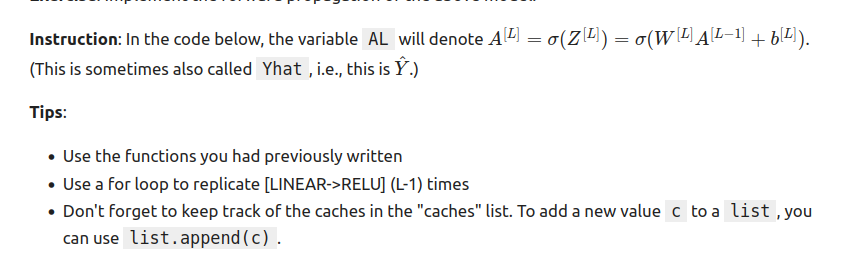


In [10]:
def L_model_forward(X, parameters):

    caches = []
    A = X
    L = len(parameters) // 2

    # [LINEAR -> RELU] for layers 1 to L-1
    for l in range(1, L):
        A_prev = A
        A, cache = linear_activation_forward(
            A_prev,
            parameters["W" + str(l)],
            parameters["b" + str(l)],
            activation="relu"
        )
        caches.append(cache)

    # [LINEAR -> SIGMOID] for last layer
    AL, cache = linear_activation_forward(
        A,
        parameters["W" + str(L)],
        parameters["b" + str(L)],
        activation="sigmoid"
    )
    caches.append(cache)

    assert(AL.shape == (1, X.shape[1]))

    return AL, caches


In [11]:
# def L_model_forward(X, parameters):
#   """
#   Implement forward propagation for the [LINEAR->RELU]*(L-1)->LINEAR->SIGMOID computation

#   Arguments :
#   X -- data, numpy array of shape (input size, number of examples)
#   parameters -- output of initialize_parameters_deep()
#   Returns:
#   AL -- last post-activation value
#   caches -- list of caches containing:
#               every cache of linear_relu_forward() (there are L-1 of them, indexed from 0 to L-2)
#               the cache of linear_sigmoid_forward() (there is one, indexed L-1)
#   """

#   caches = []

#   A = X
#   L = len(parameters) // 2  # number of layers in the neural network

#   # Implement [LINEAR -> RELU]*(L-1). Add "cache" to the "caches" list.

#   for l in range(1, L):
#     A_prev = A
#     A, cache = linear_activation_forward(A_prev,
#                                          parameters["W" + str(l)],
#                                          parameters["b" + str(l)],
#                                          activation='relu')

#     caches.append(cache)

#   AL, cache = linear_activation_forward(A,
#                                         parameters["W" + str(L)],
#                                         parameters["b" + str(L)],
#                                         activation='sigmoid')

#   caches.append(cache)

#   assert(AL.shape == (1, X.shape[1]))

#   return AL, caches









In [12]:
X, parameters = L_model_forward_test_case()
AL, caches = L_model_forward(X, parameters)

print("AL = " + str(AL))

print("Length of caches list = " + str(len(caches)))

AL = [[0.17007265 0.2524272 ]]
Length of caches list = 2


Great! Now we have a full forward propagation that takes the input X and outputs a row vector  $A^{[L]}$
containing uro predictions. It also records all intermediate values in "caches". Using  $A^{[L]}$

, we can compute the cost of our predictions.


## Cost function
Now we will implement forward and backward propagation. we need to compute the cost, because we want to check if our model is actually learning.
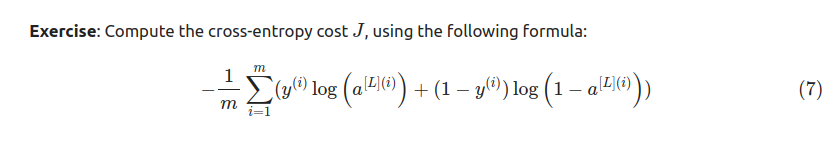

In [13]:
def compute_cost(AL, Y):
  """
  Implement the cost function defined by equation (7).

  Arguments:
  AL -- probability vector corresponding to your label predictions, shape (1, number of examples)
  Y -- true "label" vector (for example: containing 0 if non-cat, 1 if cat), shape (1, number of examples)

  Returns:
  cost -- cross-entropy cost
  """

  m = Y.shape[1]

  cost = (-1 / m) * np.sum(np.multiply(Y, np.log(AL)) + np.multiply(1 - Y, np.log(1 - AL)))

  cost = np.squeeze(cost)

  assert(cost.shape == ())

  return cost


In [14]:
Y, AL = compute_cost_test_case()

print("cost = " + str(compute_cost(AL, Y)))

cost = inf


/tmp/ipython-input-981447804.py:15: RuntimeWarning: divide by zero encountered in log
  cost = (-1 / m) * np.sum(np.multiply(Y, np.log(AL)) + np.multiply(1 - Y, np.log(1 - AL)))


## Backward propagation Module
Just like with forward propagation, you will implement helper functions for backpropagation. Remember that back propagation is used to calculate the gradient of the loss function with respect to the parameters.

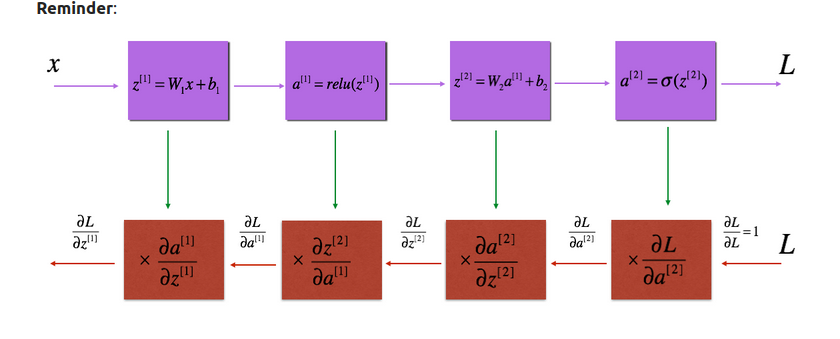


**Figure 3** : Forward and Backward propagation for *LINEAR->RELU->LINEAR->SIGMOID*
*The purple blocks represent the forward propagation, and the red blocks represent the backward propagation.*

Now, similar to forward propagation, you are going to build the backward propagation in three steps:
* LINEAR backward
* LINEAR -> ACTIVATION backward where ACTIVATION computes the derivative of either the ReLU or sigmoid activation
* [LINEAR -> RELU] X (L-1) -> LINEAR -> SIGMOID backward (whole model)


### Linear Backward
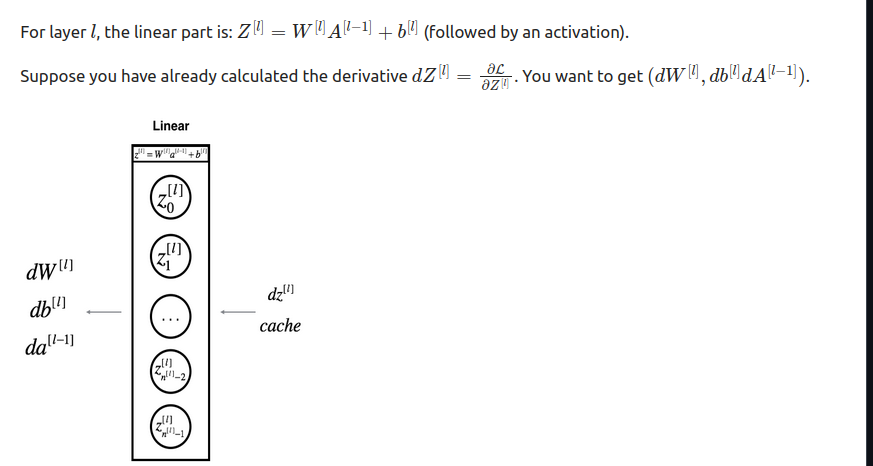



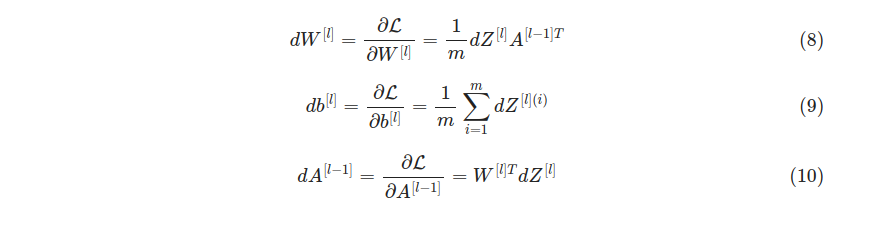

Using the formula we implement linear_backward()

In [15]:
def linear_backward(dZ, cache):
  """
    Implement the linear portion of backward propagation for a single layer (layer l)

    Arguments:
    dZ -- Gradient of the cost with respect to the linear output (of current layer l)
    cache -- tuple of values (A_prev, W, b) coming from the forward propagation in the current layer

    Returns:
    dA_prev -- Gradient of the cost with respect to the activation (of the previous layer l-1), same shape as A_prev
    dW -- Gradient of the cost with respect to W (current layer l), same shape as W
    db -- Gradient of the cost with respect to b (current layer l), same shape as b
  """

  A_prev , W, b = cache
  m = A_prev.shape[1]

  dW = np.dot(dZ, cache[0].T) /  m
  db = np.sum(np.sum(dZ, axis=1, keepdims=True)) / m
  dA_prev = np.dot(cache[1].T, dZ)

  assert (dA_prev.shape == A_prev.shape)
  assert (dW.shape == W.shape)
  assert (isinstance(db, float))


  return dA_prev, dW, db



In [16]:
# Set up some test inputs
dZ, linear_cache = linear_backward_test_case()

dA_prev, dW, db = linear_backward(dZ, linear_cache)
print ("dA_prev = "+ str(dA_prev))
print ("dW = " + str(dW))
print ("db = " + str(db))



dA_prev = [[ 2.59958052 -2.81393069]
 [-1.65956738 -1.10898707]
 [ 1.08084061 -0.78694092]
 [-2.62225928  0.88240902]]
dW = [[ 1.64992505  0.3353918   1.81763627 -0.14438459]
 [-0.05240458  0.04952957  0.71911111  0.29118497]
 [ 1.63096028  0.42501722  3.00340646  0.30244683]]
db = -1.0123412459810321


## Linear activation backward
Next, you will create a function that merges the two helper functions: `linear_backward` and the backward step for the activation `linear_activation_backward`.

*
    **sigmoid_backward**: Implements the backward propagation for SIGMOID unit. You can call it as follows:

    dZ = sigmoid_backward(dA, activation_cache)
  * **relu_backward**:     Implements the backward propagation for RELU unit. You can call it as follows:

    dZ = relu_backward(dA, activation_cache)
    if g(.) is the activation function, `sigmoid_backward` and `relu_backward` compute

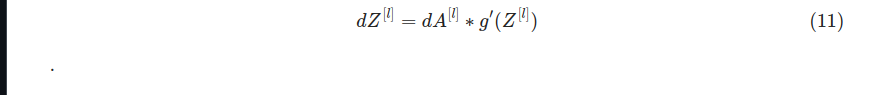






In [17]:
def linear_activation_backward(dA, cache, activation):
  """
  Implement the backward propagation for the LINEAR->ACTIVATION layer.

  Arguments:
  dA -- post-activation gradient for current layer l
  cache -- tuple of values (linear_cache, activation_cache) we store for computing backward propagation efficiently
  activation -- the activation to be used in this layer, stored as a text string: "sigmoid" or "relu"

  Returns:
  dA_prev -- Gradient of the cost with respect to the activation (of the previous layer l-1), same shape as A_prev
  dW -- Gradient of the cost with respect to W (current layer l), same shape as W
  db -- Gradient of the cost with respect to b (current layer l), same shape as b
  """

  linear_cache , activation_cache = cache

  if activation == "relu":
    dZ = relu_backward(dA, activation_cache)

  elif activation == 'sigmoid':
    dZ = sigmoid_backward(dA, activation_cache)

  dA_prev, dW, db = linear_backward(dZ, linear_cache)

  return dA_prev, dW, db

In [18]:
# Unpack all 3 values
AL, linear_activation_cache, activation = linear_activation_backward_test_case("sigmoid")

# Test sigmoid
dA_prev, dW, db = linear_activation_backward(AL, linear_activation_cache, activation="sigmoid")
print("sigmoid:")
print("dA_prev = " + str(dA_prev))
print("dW = " + str(dW))
print("db = " + str(db) + "\n")

# Test relu
AL, linear_activation_cache, activation = linear_activation_backward_test_case("relu")
dA_prev, dW, db = linear_activation_backward(AL, linear_activation_cache, activation="relu")
print("relu:")
print("dA_prev = " + str(dA_prev))
print("dW = " + str(dW))
print("db = " + str(db))


sigmoid:
dA_prev = [[ 0.09057752 -0.62764993]
 [-0.03951614  0.27382407]
 [ 0.01656211 -0.11476589]]
dW = [[0.15219351 0.1792767  0.4364216 ]]
db = -0.1539055454564083

relu:
dA_prev = [[ 2.55110313  0.        ]
 [-1.11296665  0.        ]
 [ 0.46646959  0.        ]]
dW = [[ 1.18748412 -0.38612206  0.63265968]]
db = 0.731053968522487


## L-Model backward.

Now we will implement the backward function for the whole network. Recall that when we implemented the L_model_forward function, at each iteration, we stored a cache which contains (X,W,b, and z). In the back propagation module, we will use those variables to compute the gradients. Therefore, in the L_model_backward function, we will iterate through all the hidden layers backward, starting from layer . On each step, we will use the cached values for layer to backpropagate through layer L. Figure  below shows the backward pass.

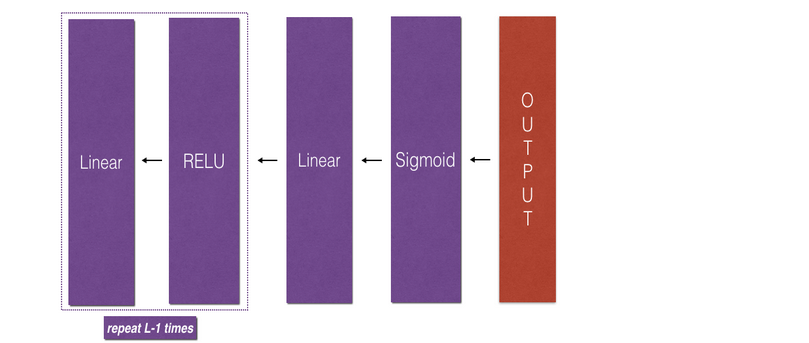


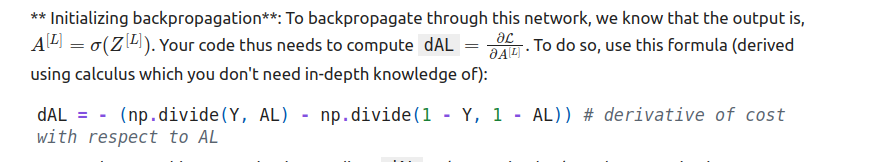



we can then use this post-activation gradient `dAL` to keep going backward. As seen in Figure , we can now feed in `dAL` into the LINEAR->SIGMOID backward function we implemented (which will use the cached values stored by the L_model_forward function). After that, we will have to use a `for` loop to iterate through all the other layers using the LINEAR->RELU backward function. we should store each dA, dW, and db in the grads dictionary. To do so, use this formula :

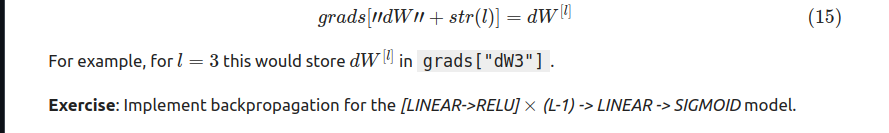


In [19]:
def L_model_backward(AL, Y, caches):
  """
  Implement the backward propagation for the [LINEAR->RELU]*(L-1) -> LINEAR->SIGMOID group
  Arguments:
  AL -- probability vector, output of the forward propagation (L_model_forward())
  Y -- true "label" vector (containing 0 if non-cat, 1 if cat)
  caches -- list of caches containing:
              every cache of linear_activation_forward() with "relu" (it's caches[l], for l in range(L-1) i.e l = 0...L-2)
              the cache of linear_activation_forward() with "sigmoid" (it's caches[L-1])

  Returns:
  grads -- A dictionary with the gradients
          grads["dA" + str(l)] = ...
          grads["dW" + str(l)] = ...
          grads["db" + str(l)] = ...
  """

  grads = {}
  L = len(caches)  # number of layers
  m = AL.shape[1]
  Y = Y.reshape(AL.shape)

  # Initialize dAL
  dAL = - (np.divide(Y, AL) - np.divide(1 - Y, 1 - AL))

  # Lth layer (SIGMOID -> LINEAR)
  current_cache = caches[-1]
  dA_prev_temp, dW_temp, db_temp = linear_activation_backward(dAL, current_cache, activation="sigmoid")
  grads["dA" + str(L)] = dA_prev_temp
  grads["dW" + str(L)] = dW_temp
  grads["db" + str(L)] = db_temp

  # Loop from L-2 to 0 (hidden layers, ReLU)
  for l in reversed(range(L - 1)):
      current_cache = caches[l]
      dA_prev_temp, dW_temp, db_temp = linear_activation_backward(grads["dA" + str(l + 2)], current_cache, activation="relu")
      grads["dA" + str(l + 1)] = dA_prev_temp
      grads["dW" + str(l + 1)] = dW_temp
      grads["db" + str(l + 1)] = db_temp

  return grads












In [20]:
X_assess, Y_assess, AL, caches = L_model_backward_test_case()

grads = L_model_backward(AL, Y_assess, caches)
print ("dW1 = "+ str(grads["dW1"]))
print ("db1 = "+ str(grads["db1"]))
print ("dA1 = "+ str(grads["dA1"]))

dW1 = [[-0.09807948  0.0318915  -0.05225412]
 [ 0.02966908  0.05203705  0.11162048]
 [ 0.0187121   0.00500243  0.02719042]
 [ 0.          0.          0.        ]]
db1 = -0.10935911793141269
dA1 = [[-0.01985035  0.18006043]
 [ 0.01199512  0.05044849]
 [-0.1794074   0.04025795]]


## Update parameters

IN this section we update the parameters of the model, using the gradient descent.

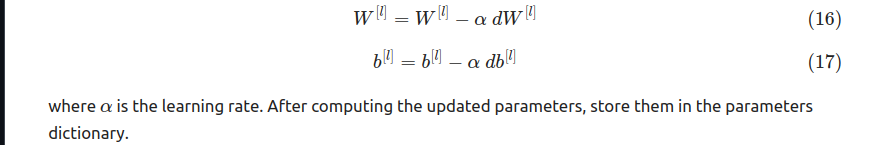

Here is the implementation of the `update_parameters()` to update the parameters using the gradient descent .
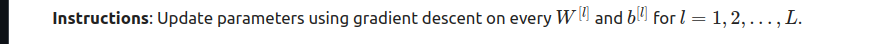


In [21]:
def update_parameters(parameters, grads, learning_rate):
  """
  Update parameters using gradient descent

  Arguments:
  parameters -- python dictionary containing your parameters
  grads -- python dictionary containing your gradients, output of L_model_backward

  Returns:
  parameters -- python dictionary containing your updated parameters
                parameters["W" + str(l)] = ...
                parameters["b" + str(l)] = ...
  """

  L = len(parameters) // 2
  for l in range(L):
    parameters["W" + str(l + 1)] = parameters["W" + str(l + 1)] - learning_rate * grads["dW" + str(l + 1)]
    parameters["b" + str(l + 1)] = parameters["b" + str(l + 1)] - learning_rate * grads["db" + str(l + 1)]

  return parameters


In [26]:
parameters , grads = update_parameters_test_case()

parameters = update_parameters(parameters, grads, 0.1)

print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))
# print("W3 = " + str(parameters["W3"]))
# print("b3 = ") + str(parameters["b3"])

W1 = [[-0.41766037  0.03154396 -2.12055268  1.61461376]
 [-1.69455768 -0.80786517  0.52649982 -1.18152259]
 [-0.93919099 -0.76688589  0.56680356  2.31911371]]
b1 = [[-0.18159729]
 [-0.87444869]
 [ 0.52778567]]
W2 = [[-0.63320415 -0.15509388  1.1248155 ]]
b2 = [[-0.66344958]]
